In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pipeline.src.python.config as cfg
from loguru import logger
import pandas as pd
pd.set_option('display.max_colwidth', None)

## CONFIGURATION

In [3]:
MAGAZINE = 'science_news'
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)
cfg_dict = cfg.MAGAZINE_CONFIG[MAGAZINE]


In [4]:
log_file = cfg_dict['LOG_PATH']

logger.add(
    str(log_file),
    rotation="10 MB",
    encoding="utf-8",
    enqueue=True,
    format="{time:YYYY-MM-DD HH:mm:ss} | {level} | {message}"       
)

1

In [5]:
from sentence_transformers import SentenceTransformer
import torch
import pandas as pd
import numpy as np
import os

os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"

logger.info(f"Set number of thread to: {os.environ["OMP_NUM_THREADS"]}")

torch.set_num_interop_threads(16)
torch.set_num_threads(16)

2025-12-23 11:43:58.680 | INFO     | __main__:<module>:10 - Set number of thread to: 16


## Embedding creations

In [6]:
df = pd.read_parquet(cfg_dict['DATASET_PATH'])

text = df['text'].to_list()

In [7]:
len(df)

1401

In [8]:
model = SentenceTransformer(cfg.EMBEDDING_MODEL,device='cpu')
embeddings = model.encode(text,
                            show_progress_bar=True,
                            convert_to_numpy=True,
                            normalize_embeddings=True
                             )

np.save(cfg_dict['OUTPUT_PATH'], embeddings, allow_pickle=False)

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

## Lemmatize and create the model

In [9]:
import spacy
import polars as pl

In [10]:
lemmatizer = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner", "textcat"]
)

In [11]:
df = pd.read_parquet(cfg_dict['DATASET_PATH'])

df_polars = pl.from_pandas(df)

In [13]:
column_to_apply_lemma = 'text'
texts = df_polars.select(column_to_apply_lemma)[column_to_apply_lemma].to_list()
    
sentences = []
    
for doc in lemmatizer.pipe(texts, batch_size=2000): 

    text_cleaned = " ".join(
        token.lemma_.lower()
        for token in doc
            if len(token.lemma_) > 2
            and not token.lemma_.isdigit()
            and not token.is_punct
            and not token.is_space
    )
    
    sentences.append(text_cleaned)
    
df_polars = df_polars.with_columns(
    pl.Series(f'{column_to_apply_lemma}_cleaned', sentences)
)

In [14]:
df_polars.select('text','text_cleaned').to_pandas().to_csv('removing_tokens.csv',sep='ç')

In [14]:
df_polars.drop('text').rename({'text_cleaned':'text'}).to_pandas().to_parquet(cfg_dict['PROCESSED_PATH'])

## Model hyperparameter

In [15]:
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from transformers import AutoTokenizer
from transformers.pipelines import pipeline
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid,ParameterSampler
from sklearn.manifold import trustworthiness

### Parameters

In [16]:
SAMPLE_PERCENTAGE = 1
PARAMETER_PERCENTAGE = 1
MINIMUM_SCORE_TO_SAVE_MODEL = 0.25

UMAP
- umap__n_neighbors --> quanti vicini considerare per creare il grafo per costruire lo spazio vettoriale a bassa dimensionalità ( + è alto più si ha una visione globale, + è basso più si ha una visione locale dei cluster)
- umap__min_dist --> è la distanza minima ammessa tra due punti nello spazio a bassa dimensionalità (proiezione)
- umap__n_components --> numero di dimensioni della proiezione

HDBSCAN
- hdbscan__min_samples --> determina quanto un punto deve essere in una zona densa per non essere considerato rumore (+ è alto meno è permissivo con il rumore, + è basso e più è permissivo)
- hdbscan__min_cluster_size --> minimo numero di elementi per considerare un cluster
- hdbscan__cluster_selection_method --> determina come scegliere i cluster partendo dalla struttura gerarchica che crea l'algoritmo ( leaf parte dalle foglie, eom (exceed of mass) utilizza un metodo statistico ) 
- hdbscan__metric --> metrica di distanza adottata nel clustering

Consigli:
- Utilizzare cosine in Umap e euclidian in hdbscan


In [17]:
param_grid = cfg_dict['HYPERPARAMETER_GRID']

In [18]:
total_permutation = len(ParameterGrid(param_grid=param_grid)) * PARAMETER_PERCENTAGE
number_of_sample = np.ceil(total_permutation)

### Model creation

In [19]:
from bertopic.representation import MaximalMarginalRelevance 
def create_model(umap_model_, hdbscan_model_):
    """
    Create a BERTopic model with the initialized UMAP and HDBSCAN models
    """
    vectorizer_model = CountVectorizer(
        stop_words=list(STOP_WORDS)+cfg_dict['DOMAIN_SPECIFIC_STOP_WORDS'],
        token_pattern="(?u)\\b[\\w-]+\\b",
        ngram_range=(1, 2)
    )
    ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

    representation_model = [KeyBERTInspired(),MaximalMarginalRelevance(diversity=0.3)]

    # Use a predefined pytorch pipeline for feature extraction to compute embeddings
    tokenizer = AutoTokenizer.from_pretrained(cfg.EMBEDDING_MODEL)
    embedding_model = pipeline(
        task="feature-extraction",
        model=cfg.EMBEDDING_MODEL,
        tokenizer=tokenizer,
        device="cpu",
        trust_remote_code=True
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model_,  # Step 2 - Reduce dimensionality
        hdbscan_model=hdbscan_model_,  # Step 3 - Cluster reduced embeddings
        vectorizer_model=vectorizer_model,  # Step 4 - Tokenize topics
        ctfidf_model=ctfidf_model,  # Step 5 - Extract topic words
        representation_model=representation_model,  # Step 6 - (Optional) Fine-tune topic represenations
        verbose=True,
    )

    return topic_model

### Data sampling for hyperparameter tuning

In [20]:
with open(cfg_dict['OUTPUT_PATH'],mode='rb') as f:
    embeddings = np.load(f,allow_pickle=False)

data_mask = np.random.choice(
    [False,True],
    len(embeddings),
    p=[1-SAMPLE_PERCENTAGE,SAMPLE_PERCENTAGE]
    )

embeddings_sample = embeddings[data_mask]

### Pipeline

In [21]:
df = pd.read_parquet(cfg_dict['PROCESSED_PATH'])

documents = list(df['text'])

In [22]:
param_list = list(ParameterSampler(param_grid,number_of_sample,random_state=42))

In [23]:

RANK_PATH = f'/home/banfi/TETYS/pipeline/src/python/data/interim/rank/{MAGAZINE}_rank.json'

In [24]:
import json
best_score = -1

for idx, params in enumerate(param_list):

    umap_params = {k.split("__",1)[1]: v for k,v in params.items() if k.startswith("umap__")}
    hdbscan_params = {k.split("__",1)[1]: v for k,v in params.items() if k.startswith("hdbscan__")}

    logger.info("=" * 80)
    logger.info(f"RUN {idx} | umap_params={umap_params} | hdbscan_params={hdbscan_params}")
    logger.info("=" * 80)

    umap = UMAP(random_state=42)

    hdbscan = HDBSCAN(gen_min_span_tree=True,prediction_data=True)

    umap.set_params(**umap_params)
    hdbscan.set_params(**hdbscan_params)

    logger.info(f"Umap run starts")
    umap_reduction = umap.fit_transform(embeddings_sample)
    logger.info(f"Umap run finished")

    trust = trustworthiness(
        X = embeddings_sample,
        X_embedded = umap_reduction,
        n_neighbors= umap_params['n_neighbors'],
        metric = umap_params['metric']
    )

    logger.info(f"Umap trustworthiness {trust}")

    logger.info(f"Hdbscan run starts")
    hdbscan.fit(umap_reduction)
    logger.info(f"Hdbscan run finished")

    labels = hdbscan.labels_
    logger.info(f"Hdbscan has produced {len(set(labels))} clusters")

    if -1 in labels:
        n_outlier_articles = (labels == -1).sum()
        proportion = (n_outlier_articles/len(labels))*100
        logger.info(f"Hdbscan has produced the outlier cluster composed by {n_outlier_articles}")
        logger.info(f"The {proportion:.2f}%")

    current_score = hdbscan.relative_validity_

    logger.info(f"DBCV score is: {current_score}")
    

    if current_score > best_score and current_score > MINIMUM_SCORE_TO_SAVE_MODEL:
        
        best_score = current_score
        best_parameters = params

        logger.info("Creating a BERTopic model")

        model = create_model(umap_model_=umap,hdbscan_model_=hdbscan)
            
        logger.info(f"BERTopic model created with DBCV score {best_score}")

        logger.info("Fitting the model and transforming data...")
            
        topics, probs = model.fit_transform(documents,embeddings=embeddings)

        logger.info(f"DBCV score (Refitted model): {model.hdbscan_model.relative_validity_}")

        model.save(
            cfg_dict['MODEL_PATH'] + f"model_{best_score:.3f}.safetensors",
            serialization="safetensors",
            save_ctfidf=True,
            save_embedding_model=False,
        )

        logger.info(f"Parameters {params}")
        logger.info(f"DBCV score :{best_score:.3f}")
        logger.info(f"Model saved in {cfg_dict['MODEL_PATH']}")
    else:
        logger.info('Score rejected')

if best_score != -1:
    rank = (best_parameters,best_score)
    #rank_list.append(rank)

    with open(RANK_PATH,mode='r',encoding='utf-8') as file:
        old_rank = json.load(file)

    old_rank.append(rank)
    old_rank_sorted = sorted(old_rank,key=lambda x: x[1],reverse=True)
    print(old_rank)
    print(old_rank_sorted)

    print(f"The best score parameters score is {old_rank_sorted[0][1]} with the following parameters {old_rank_sorted[0][0]} ")

    with open(RANK_PATH,mode='w',encoding='utf-8') as file:
        json.dump(old_rank_sorted,file)


            


2025-12-22 15:56:24.028 | INFO     | __main__:<module>:9 - ================================================================================
2025-12-22 15:56:24.030 | INFO     | __main__:<module>:10 - RUN 0 | umap_params={'n_neighbors': 10, 'n_components': 10, 'min_dist': 0.0, 'metric': 'cosine'} | hdbscan_params={'min_samples': 5, 'min_cluster_size': 20, 'metric': 'euclidean', 'cluster_selection_method': 'eom'}
2025-12-22 15:56:24.031 | INFO     | __main__:<module>:11 - ================================================================================
2025-12-22 15:56:24.033 | INFO     | __main__:<module>:20 - Umap run starts
2025-12-22 15:56:39.883 | INFO     | __main__:<module>:22 - Umap run finished
2025-12-22 15:56:40.097 | INFO     | __main__:<module>:31 - Umap trustworthiness 0.938736135013115
2025-12-22 15:56:40.098 | INFO     | __main__:<module>:33 - Hdbscan run starts
2025-12-22 15:56:40.158 | INFO     | __main__:<module>:35 - Hdbscan run finished
2025-12-22 15:56:40.159 | INFO 

[({'umap__n_neighbors': 10, 'umap__n_components': 15, 'umap__min_dist': 0.0, 'umap__metric': 'cosine', 'hdbscan__min_samples': 10, 'hdbscan__min_cluster_size': 70, 'hdbscan__metric': 'euclidean', 'hdbscan__cluster_selection_method': 'eom'}, np.float64(0.7572330004394461))]
[({'umap__n_neighbors': 10, 'umap__n_components': 15, 'umap__min_dist': 0.0, 'umap__metric': 'cosine', 'hdbscan__min_samples': 10, 'hdbscan__min_cluster_size': 70, 'hdbscan__metric': 'euclidean', 'hdbscan__cluster_selection_method': 'eom'}, np.float64(0.7572330004394461))]
The best score parameters score is 0.7572330004394461 with the following parameters {'umap__n_neighbors': 10, 'umap__n_components': 15, 'umap__min_dist': 0.0, 'umap__metric': 'cosine', 'hdbscan__min_samples': 10, 'hdbscan__min_cluster_size': 70, 'hdbscan__metric': 'euclidean', 'hdbscan__cluster_selection_method': 'eom'} 


## Representation Update

In [143]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

DATASET_PATH = "/home/banfi/Tesi/data/processed/science_news/pipeline_data/science_news_pipeline_data.parquet"
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)
SCIENCE_NEWS_STOP_WORDS = ['activity','appear','carry','cause','close','detailed','discuss','end','fight','find','help','infect','insert','issue','kind','large','learn','like','look','need','news','number','overcome','play','produce','protect','publish','recent','reduce','report','researcher','reveal','risk','science','scientific','scientist','separate','small','someday','story','study','suggest','tighly','unvealing',
'use','watch','work']

df = pd.read_parquet(DATASET_PATH)
documents = df[DATASET_TEXT_FEATURE].apply(str).to_list()

vectorizer_model = CountVectorizer(
        stop_words=list(STOP_WORDS)+SCIENCE_NEWS_STOP_WORDS,
        token_pattern="(?u)\\b[\\w-]+\\b",
        ngram_range=(1, 2)
    )

# ricalcola rappresentazione (c-TF-IDF) senza rifare clustering
model.update_topics(documents, vectorizer_model=vectorizer_model)

In [144]:
model.visualize_topics().show()

## Model representation

In [27]:
from bertopic import BERTopic
import pandas as pd

DATASET_PATH = "/home/banfi/Tesi/data/processed/science_news/pipeline_data/science_news_pipeline_data_last.parquet"
DATASET_TEXT_FEATURE = (
    "text"  # In the dataset file, the column name that contains the text data
)

df = pd.read_parquet(DATASET_PATH)
documents = df[DATASET_TEXT_FEATURE].apply(str).to_list()

#model_path = '/home/banfi/TETYS/pipeline/src/python/models/science_news/model_0.387.safetensors'
#model_path = '/home/banfi/TETYS/pipeline/src/python/models/science_news/model_0.377.safetensors'
#model_path = '/home/banfi/TETYS/pipeline/src/python/models/science_news/model_0.545.safetensors'
model_path = '/home/banfi/TETYS/pipeline/src/python/models/science_news/model_0.561.safetensors'
model = BERTopic.load(model_path, 
                      embedding_model='sentence-transformers/all-MiniLM-L6-v2'
                      )


model.visualize_topics().show()

In [28]:
model.visualize_heatmap().show()

In [29]:

model.visualize_barchart().show()


In [30]:
model.visualize_term_rank().show()


In [31]:
model.visualize_hierarchy().show()


In [ ]:
print(model.get_topic_freq())
print(model.get_topics())

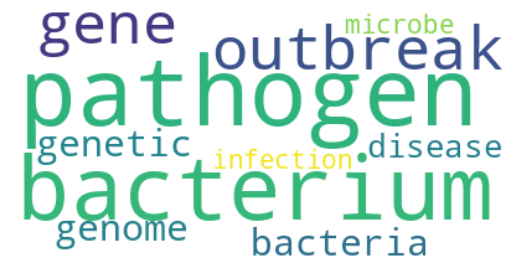

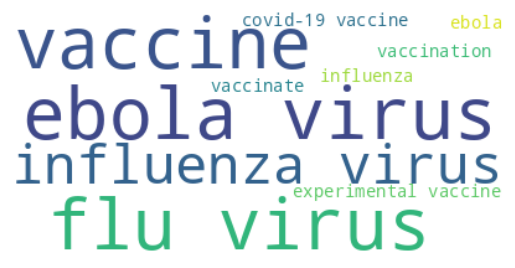

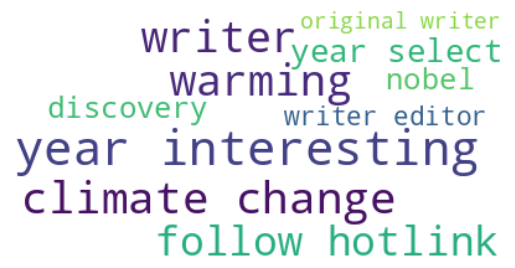

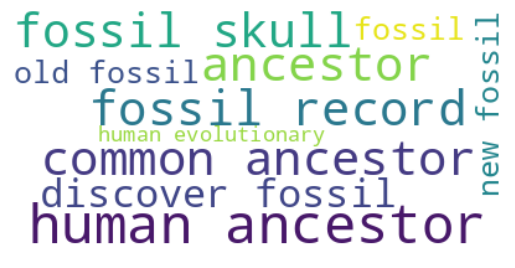

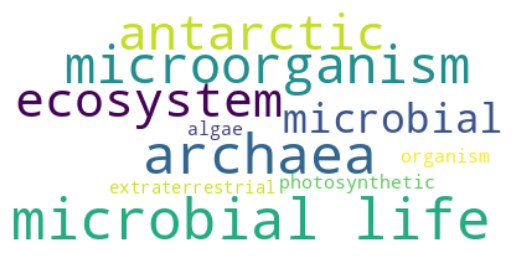

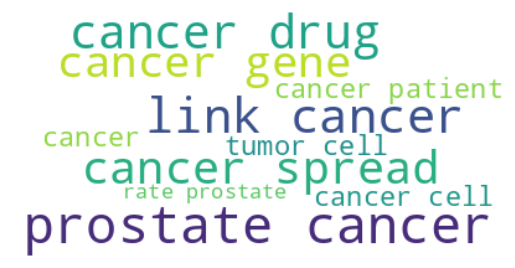

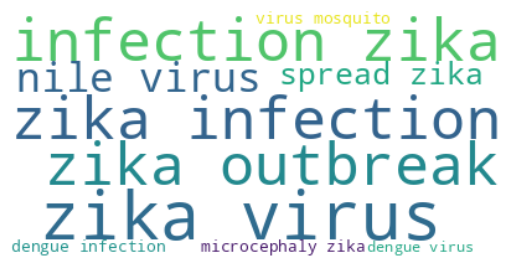

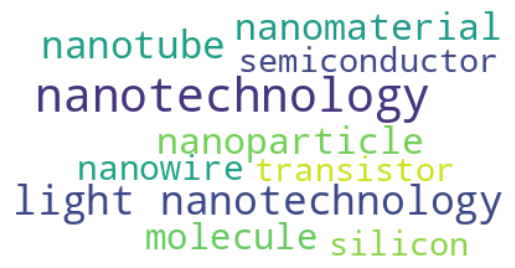

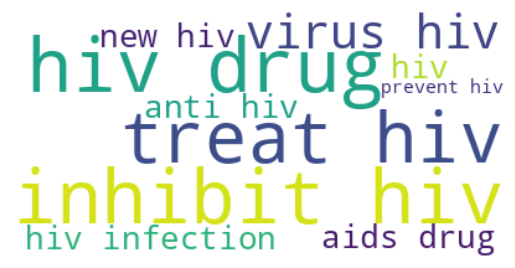

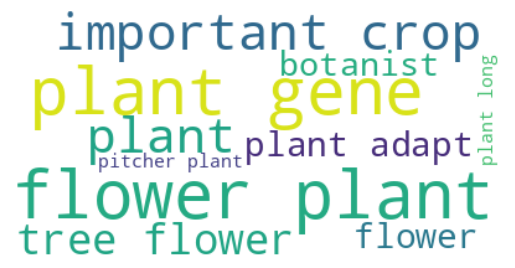

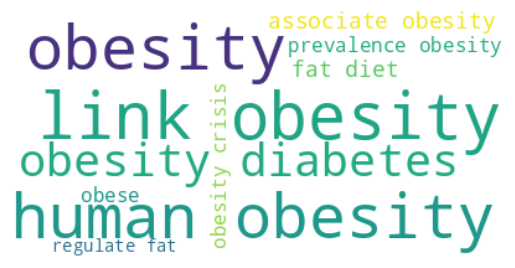

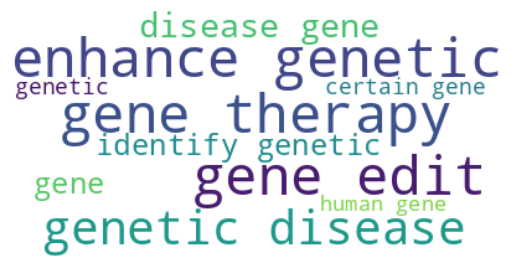

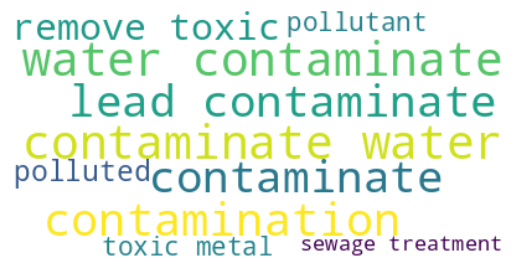

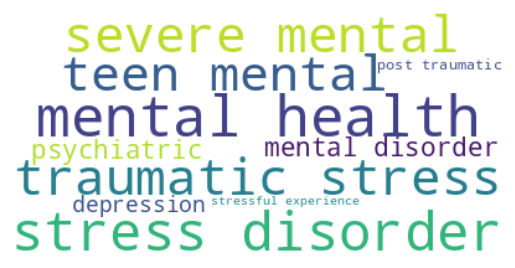

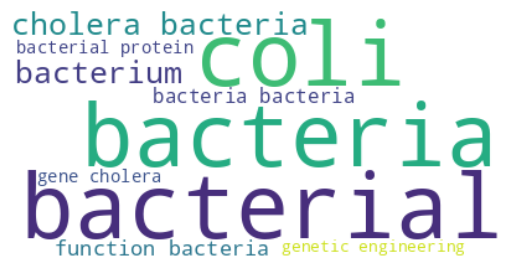

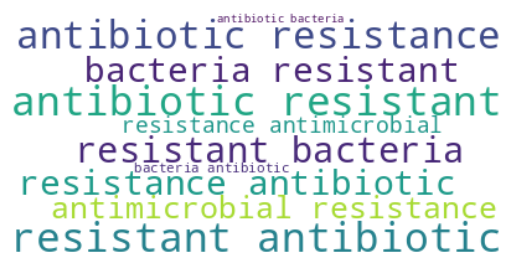

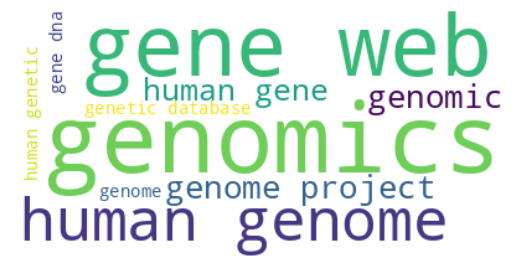

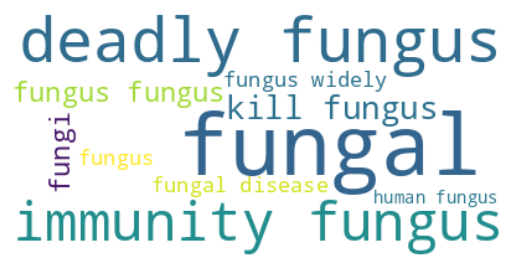

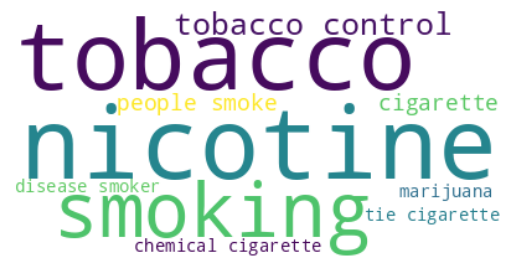

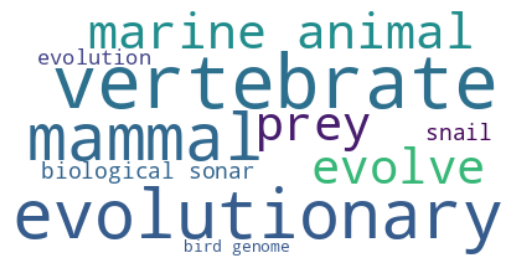

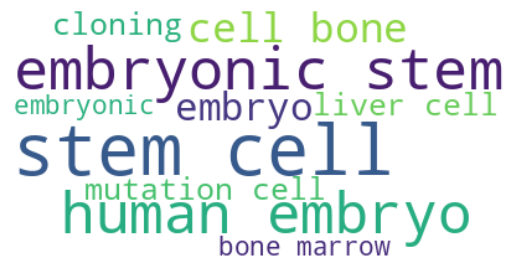

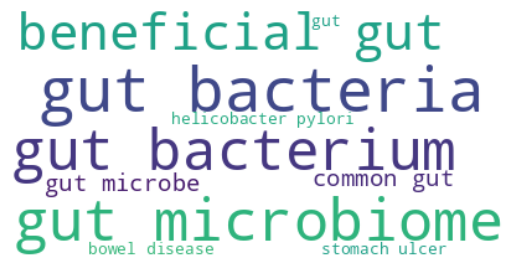

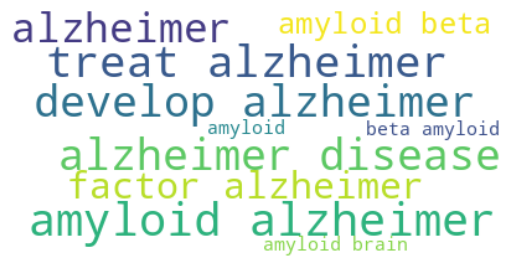

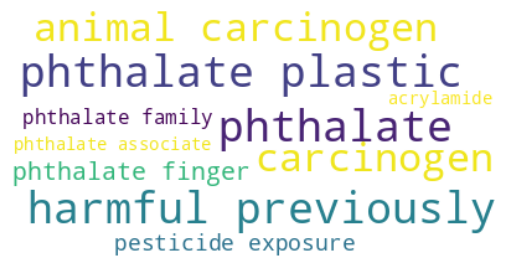

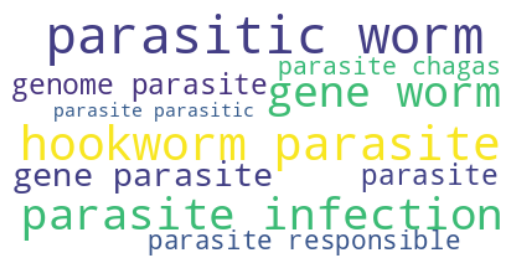

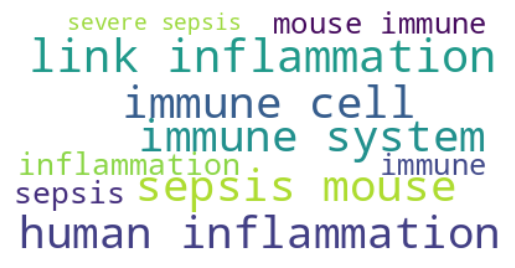

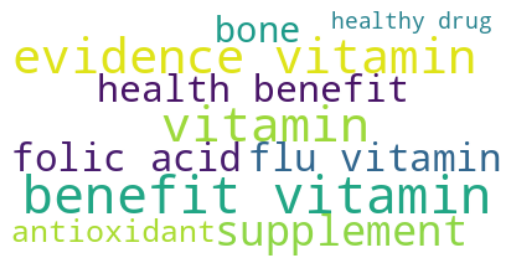

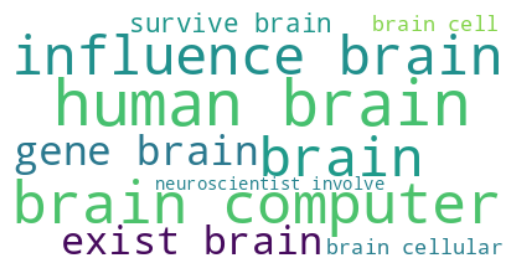

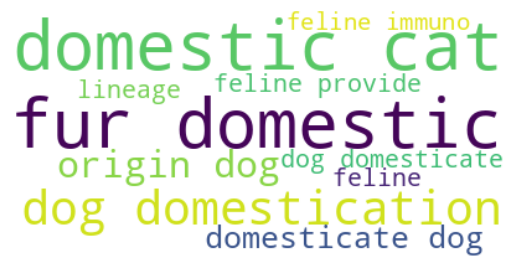

<Figure size 640x480 with 0 Axes>

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import time
def create_wordcloud(model, topic):
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud

for i in model.get_topics().keys():
    create_wordcloud(model, topic=i)
    time.sleep(10)
    plt.clf()

In [32]:
topics_per_class = model.topics_per_class(
    df['text'],
    classes=df['score_bin']
)

#selected_topics = [24]

model.visualize_topics_per_class(
    topics_per_class,
    #topics=selected_topics,
    normalize_frequency = True
)

11it [00:00, 13.42it/s]


In [36]:
topics_per_class = model.topics_per_class(
    df['text'],
    classes=df['score_bin']
)

selected_topics = list(range(10,20))

model.visualize_topics_per_class(
    topics_per_class,
    topics=selected_topics,
    normalize_frequency = True
)

11it [00:01,  8.85it/s]


In [10]:
df = pd.read_parquet(DATASET_PATH)

text = df['text'].to_list()

## Seach articles from topic id

In [34]:
df.columns

Index(['id', 'document_score', 'best_sentence', 'keywords_critic_matched',
       'keywords_high_matched', 'keywords_normal_matched',
       'keywords_low_matched', 'keywords_critic_matched_count',
       'keywords_high_matched_count', 'keywords_normal_matched_count',
       'keywords_low_matched_count', 'publicationDate', 'status', 'title',
       'content', 'text', 'metadata', 'tags', 'categories', 'authors',
       'n_tags', 'n_categories', 'n_authors', 'keywords_critic_in_title',
       'keywords_high_in_title', 'keywords_normal_in_title',
       'keywords_low_in_title', 'title_presence_multiplier', 'section_score',
       'final_document_score', 'score_bin'],
      dtype='object')

In [11]:
df[ df['keywords_high_matched'].isin(['spillover'])]

,id,document_score,best_sentence,keywords_critic_matched,keywords_high_matched,keywords_normal_matched,keywords_low_matched,keywords_critic_matched_count,keywords_high_matched_count,keywords_normal_matched_count,...,n_categories,n_authors,keywords_critic_in_title,keywords_high_in_title,keywords_normal_in_title,keywords_low_in_title,title_presence_multiplier,section_score,final_document_score,score_bin


In [13]:
import numpy as np

topic_id = 1
indices = np.where( np.array(model.topics_) == topic_id)[0]

topic_docs = [ text[i] for i in indices ]

In [14]:
columns_to_extract = ['categories', 'final_document_score','title', 'best_sentence', 'keywords_critic_matched',
       'keywords_high_matched', 'keywords_normal_matched',
       'keywords_low_matched', 'text', 'categories','title_presence_multiplier', 'section_score',
       'score_bin']

cols = ['id','keywords_critic_matched',
       'keywords_high_matched', 'keywords_normal_matched',
       'keywords_low_matched']

In [15]:
 a = df[ df.text.isin(topic_docs) ].sort_values(by=['final_document_score'],ascending=False)[cols]


In [16]:
a[a.id == 'https://www.sciencenews.org/article/birdsong-track-rare-birds-purple-winged-ground-dove' ]

,id,keywords_critic_matched,keywords_high_matched,keywords_normal_matched,keywords_low_matched
451,https://www.sciencenews.org/article/birdsong-track-rare-birds-purple-winged-ground-dove,[],[spillover],[],[virus]


In [64]:
list_of_keywords = [ key  for list_of_key in a.keywords_high_matched for key in list_of_key ]

In [82]:
a[ a['keywords_high_matched'].isin(['transmission chain'])]

,id,keywords_critic_matched,keywords_high_matched,keywords_normal_matched,keywords_low_matched


In [65]:
set(list_of_keywords)

{'Clade',
 'Hai',
 'Recombination',
 'clade',
 'genetic drift',
 'horizontal gene transfer',
 'phylogeny',
 'recombination',
 'spill over',
 'spillover',
 'transmission chain'}

## View documents and topics

In [30]:
model.visualize_documents(text, embeddings=embeddings)
